# Classification


## MNIST Dataset:

In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()
X, y = mnist["data"], mnist["target"]
X.shape

(70000, 784)

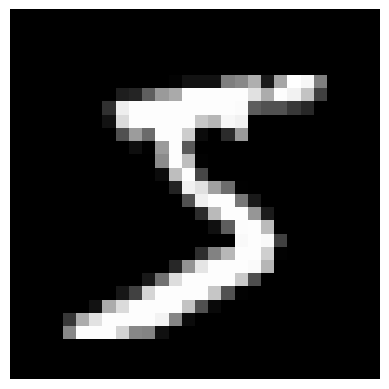

Etiqueta (y[0]): 5

Pixel matrix (28x28) - formatted:
00:   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
01:   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
02:   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
03:   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
04:   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
05:   0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0
06:   0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0
07:   0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0
08:   0   0   0   

In [2]:
import matplotlib.pyplot as plt
import numpy as np

some_digit = X.iloc[0].to_numpy()
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap="gray")
plt.axis("off")
plt.show()

print("Etiqueta (y[0]):", y.iloc[0])
print("\nPixel matrix (28x28) - formatted:")
pixel_matrix = some_digit_image.astype(np.uint8)
for row_idx, row in enumerate(pixel_matrix):
    row_values = " ".join(f"{value:3d}" for value in row)
    print(f"{row_idx:02d}: {row_values}")

print("\nTipo:", some_digit_image.dtype)
print("Min pixel:", some_digit_image.min(), "| Max pixel:", some_digit_image.max())

## Cutting the dataset into training and testing sets

In [3]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:70000], y[:60000], y[60000:70000]

## Binary classification: Is the digit 5 or not?

In [4]:
y_train_5 = (y_train == "5")
y_test_5 = (y_test == "5")

## Training the model

In [5]:
import numpy as np

print("y_train dtype:", y_train.dtype)
print("classes y_train:", np.unique(y_train)[:10], " ... total:", len(np.unique(y_train)))

# Se y_train for string, compare com "5"; se for numérico, compare com 5
y_train_5 = (y_train == "5") if y_train.dtype.kind in {"U", "S", "O"} else (y_train == 5)

print("classes y_train_5:", np.unique(y_train_5), "counts:", np.bincount(y_train_5.astype(int)))

y_train dtype: category
classes y_train: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']  ... total: 10
classes y_train_5: [False  True] counts: [54579  5421]


## Classification Cross Validation

In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train.iloc[train_index]
    y_train_folds = y_train_5.iloc[train_index]
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = y_train_5.iloc[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = (y_pred == y_test_fold).sum()
    print(f"Fold accuracy: {n_correct}/{len(y_pred)} = {n_correct / len(y_pred):.2%}")

Fold accuracy: 18084/20000 = 90.42%
Fold accuracy: 18954/20000 = 94.77%
Fold accuracy: 19357/20000 = 96.78%


## Seeing the accuracy

In [7]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

## The Confusion Matrix
# Confusion Matrix & Metrics (Quick Guide)

A confusion matrix compares predicted labels with true labels in a binary classifier.

## Confusion Matrix

|                | Predicted Positive | Predicted Negative |
|----------------|-------------------|-------------------|
| **Actual Positive** | TP (True Positive) | FN (False Negative) |
| **Actual Negative** | FP (False Positive) | TN (True Negative) |

Let $N = TP + TN + FP + FN$ be the total number of samples.

---

## Key Metrics

### Accuracy (General Correctness)
Overall proportion of correct predictions:

$$
\mathrm{Accuracy} = \frac{TP + TN}{N} = \frac{TP + TN}{TP + TN + FP + FN}
$$

### Precision (Positive Predictive Value) (True positives and false positives right measure, alert positives was right)
Among predicted positives, how many are truly positive:

$$
\mathrm{Precision} = \frac{TP}{TP + FP}
$$

Focus: false positives.

### Recall (Sensitivity, True Positive Rate) (How many positives are correctly found, by passing)
Among actual positives, how many are correctly found:

$$
\mathrm{Recall} = \frac{TP}{TP + FN}
$$

Focus: false negatives.

### F1-Score
Harmonic mean of Precision and Recall:

$$
F_1 = 2\,\frac{\mathrm{Precision}\cdot\mathrm{Recall}}{\mathrm{Precision}+\mathrm{Recall}}
$$

Equivalent form:

$$
F_1 = \frac{2TP}{2TP + FP + FN}
$$

---

## Extra Useful Metrics

Specificity (True Negative Rate):

$$
\mathrm{Specificity} = \frac{TN}{TN + FP}
$$

False Positive Rate:

$$
\mathrm{FPR} = \frac{FP}{FP + TN} = 1 - \mathrm{Specificity}
$$

False Negative Rate:

$$
\mathrm{FNR} = \frac{FN}{FN + TP} = 1 - \mathrm{Recall}
$$

---

## When To Use What?

- **Accuracy**: best when classes are balanced and errors have similar cost.
- **Precision**: best when false positives are expensive.
- **Recall**: best when missing positives is expensive.
- **F1-score**: best when you need a balance between Precision and Recall.

In [8]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [9]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

cm = confusion_matrix(y_train_5, y_train_pred)
print("Confusion Matrix:\n", cm)

print("Accuracy:", accuracy_score(y_train_5, y_train_pred))
print("Precision:", precision_score(y_train_5, y_train_pred))
print("Recall:", recall_score(y_train_5, y_train_pred))
print("F1-score:", f1_score(y_train_5, y_train_pred))

Confusion Matrix:
 [[53892   687]
 [ 1891  3530]]
Accuracy: 0.9570333333333333
Precision: 0.8370879772350012
Recall: 0.6511713705958311
F1-score: 0.7325171197343847


## The trade-off between Precision and Recall:
- Adjusting the decision threshold of a classifier can increase Precision at the cost of Recall, or vice versa. This is known as the Precision-Recall trade-off.
- For example, in a spam detection system, you might want to increase Precision to avoid marking important emails as spam, even if it means some spam emails are missed (lower Recall). Conversely, in a disease screening test, you might want to increase Recall to catch as many cases as possible, even if it means some healthy people are incorrectly flagged (lower Precision).

c:\Users\marco\Documents\code_classes\machine_learning_review\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


Decision score (some_digit): [2164.22030239]
Prediction with threshold=0: [ True]
Prediction with threshold=8000: [False]


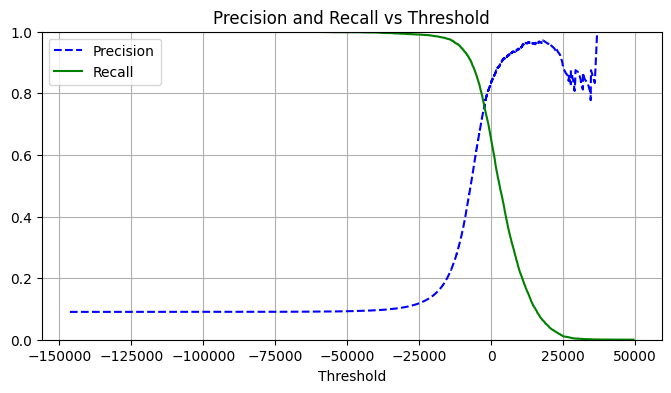

In [10]:
from sklearn.utils.validation import check_is_fitted
from sklearn.exceptions import NotFittedError
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict

# Garantir que o modelo esteja ajustado antes de usar decision_function
try:
    check_is_fitted(sgd_clf)
except NotFittedError:
    sgd_clf.fit(X_train, y_train_5)

# Score do exemplo individual
y_score = sgd_clf.decision_function([some_digit])
print("Decision score (some_digit):", y_score)

threshold = 0
y_some_digit_pred = (y_score > threshold)
print("Prediction with threshold=0:", y_some_digit_pred)

threshold = 8000
y_some_digit_pred = (y_score > threshold)
print("Prediction with threshold=8000:", y_some_digit_pred)

# Curva Precision-Recall usando validação cruzada
y_score = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    method="decision_function",
)

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_score)

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])
    plt.title("Precision and Recall vs Threshold")
    plt.grid()
    plt.show()

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)

Cyberpunk GIF saved at: C:\Users\marco\Documents\code_classes\machine_learning_review\chapters\chapter_3_classification\precision_recall_cyberpunk.gif


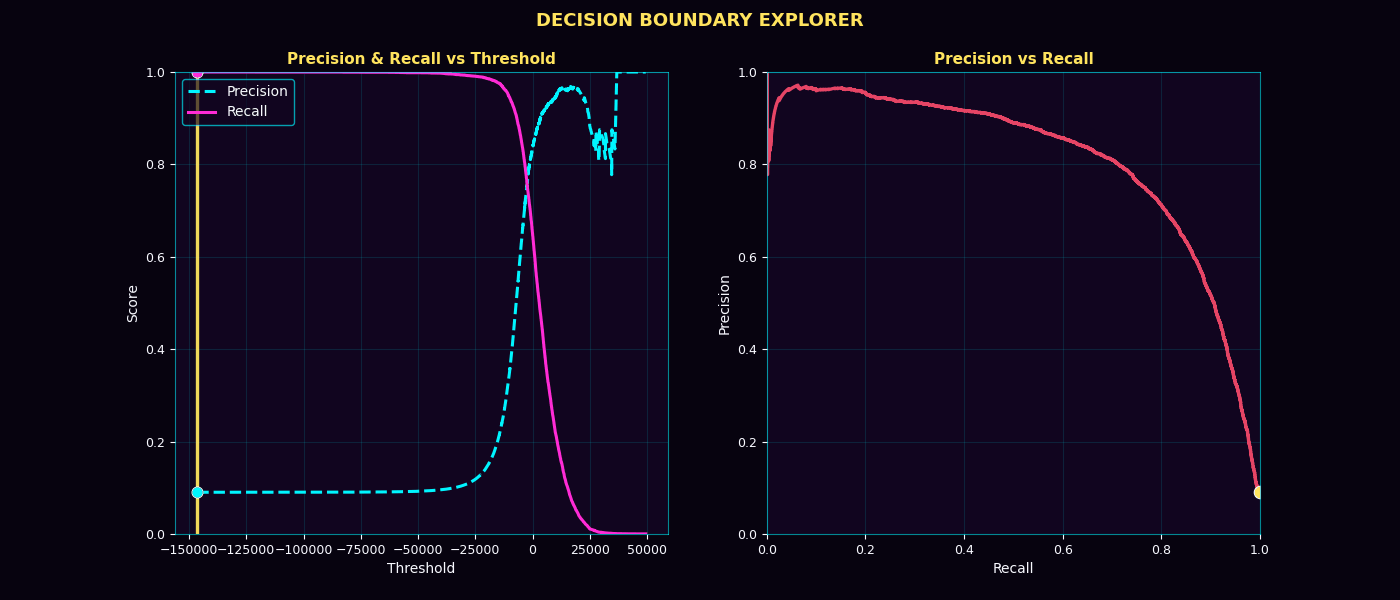

In [11]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Requires previous cell outputs: precisions, recalls, thresholds
if not all(name in globals() for name in ["precisions", "recalls", "thresholds"]):
    raise RuntimeError("Run the previous cell first to generate precisions/recalls/thresholds.")

curve_precisions = np.asarray(precisions[:-1])
curve_recalls = np.asarray(recalls[:-1])
curve_thresholds = np.asarray(thresholds)

# Keep GIF light for social sharing
n_frames = min(120, len(curve_thresholds))
frame_positions = np.linspace(0, len(curve_thresholds) - 1, n_frames).astype(int)

# Cyberpunk palette
bg_outer = "#07030f"
bg_inner = "#11051f"
cyan = "#00F5FF"
magenta = "#FF2BD6"
yellow = "#FFE45E"
neon_red = "#FF4D6D"
white = "#F8F9FF"

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=bg_outer)
ax_thr, ax_pr = axes

for ax in axes:
    ax.set_facecolor(bg_inner)
    ax.tick_params(colors=white, labelsize=9)
    for spine in ax.spines.values():
        spine.set_color(cyan)
        spine.set_alpha(0.55)
    ax.grid(True, color=cyan, alpha=0.12, linewidth=0.8)

# Chart 1: Precision/Recall vs Threshold
ax_thr.plot(curve_thresholds, curve_precisions, linestyle="--", color=cyan, linewidth=2.2, label="Precision")
ax_thr.plot(curve_thresholds, curve_recalls, linestyle="-", color=magenta, linewidth=2.2, label="Recall")
ax_thr.set_xlabel("Threshold", color=white)
ax_thr.set_ylabel("Score", color=white)
ax_thr.set_ylim([0, 1])
ax_thr.set_title("Precision & Recall vs Threshold", color=yellow, fontsize=11, fontweight="bold")
legend = ax_thr.legend(loc="upper left", facecolor=bg_inner, edgecolor=cyan, framealpha=0.65)
for text in legend.get_texts():
    text.set_color(white)

vline = ax_thr.axvline(curve_thresholds[frame_positions[0]], color=yellow, linewidth=2.4, alpha=0.95)
point_p_thr, = ax_thr.plot([], [], marker="o", color=cyan, markersize=8, markeredgecolor=white, markeredgewidth=0.6)
point_r_thr, = ax_thr.plot([], [], marker="o", color=magenta, markersize=8, markeredgecolor=white, markeredgewidth=0.6)

# Chart 2: Precision vs Recall
ax_pr.plot(curve_recalls, curve_precisions, color=neon_red, linewidth=2.4, alpha=0.9)
ax_pr.set_xlabel("Recall", color=white)
ax_pr.set_ylabel("Precision", color=white)
ax_pr.set_xlim([0, 1])
ax_pr.set_ylim([0, 1])
ax_pr.set_title("Precision vs Recall", color=yellow, fontsize=11, fontweight="bold")

point_pr, = ax_pr.plot([], [], marker="o", color=yellow, markersize=9, markeredgecolor=white, markeredgewidth=0.8)
path_pr, = ax_pr.plot([], [], color=cyan, alpha=0.5, linewidth=1.8)

overlay = fig.text(
    0.5,
    0.02,
    "",
    ha="center",
    va="bottom",
    fontsize=10,
    color=white,
    bbox={"boxstyle": "round,pad=0.35", "facecolor": bg_inner, "edgecolor": magenta, "alpha": 0.9},
)

fig.suptitle("DECISION BOUNDARY EXPLORER", color=yellow, fontsize=13, fontweight="bold", y=0.98)

def update(frame_i):
    idx = frame_positions[frame_i]
    thr = curve_thresholds[idx]
    p = curve_precisions[idx]
    r = curve_recalls[idx]

    # Update chart 1
    vline.set_xdata([thr, thr])
    point_p_thr.set_data([thr], [p])
    point_r_thr.set_data([thr], [r])

    # Update chart 2
    point_pr.set_data([r], [p])
    trail_idx = frame_positions[: frame_i + 1]
    path_pr.set_data(curve_recalls[trail_idx], curve_precisions[trail_idx])

    overlay.set_text(f"THR: {thr:.0f}   |   PRECISION: {p:.3f}   |   RECALL: {r:.3f}")

    return vline, point_p_thr, point_r_thr, point_pr, path_pr, overlay

anim = FuncAnimation(fig, update, frames=n_frames, interval=80, blit=True)

gif_path = Path("precision_recall_cyberpunk.gif")
anim.save(gif_path, writer=PillowWriter(fps=14))
plt.close(fig)

print(f"Cyberpunk GIF saved at: {gif_path.resolve()}")
display(Image(filename=str(gif_path)))

# 📈 ROC Curve & AUC — Explained Simply

## 🔍 What is the ROC Curve?

The **ROC Curve (Receiver Operating Characteristic Curve)** is a graphical tool used to evaluate the performance of a **binary classification model**.

It shows the trade-off between:

- **True Positive Rate (TPR)** → Sensitivity / Recall  
- **False Positive Rate (FPR)** → 1 - Specificity  

---

## 🧮 Key Formulas

- **True Positive Rate (TPR)**  
  \[
  TPR = \frac{TP}{TP + FN}
  \]

- **False Positive Rate (FPR)**  
  \[
  FPR = \frac{FP}{FP + TN}
  \]

---

## 📊 How the ROC Curve Works

- The curve is created by plotting **TPR (y-axis)** vs **FPR (x-axis)** at different classification thresholds.
- Each point represents a different threshold.

### 💡 Interpretation:

- 📈 Closer to the **top-left corner** → Better model
- 📉 Diagonal line → Random guessing (baseline)

---

## 🏆 What is AUC?

**AUC (Area Under the Curve)** measures the **overall performance** of the model.

- Range: **0 → 1**
  
| AUC Score | Meaning |
|----------|--------|
| 1.0      | Perfect model 🟢 |
| 0.9+     | Excellent 🚀 |
| 0.8–0.9  | Good 👍 |
| 0.7–0.8  | Fair ⚖️ |
| 0.5      | Random 😐 |
| < 0.5    | Worse than random ❌ |

---

## 🎯 Intuition

AUC answers this question:

> **"What is the probability that the model ranks a random positive example higher than a random negative one?"**

---

## ⚖️ When to Use ROC-AUC

✅ Useful when:
- Classes are **balanced**
- You care about **ranking predictions**

⚠️ Be careful when:
- Data is **highly imbalanced** → Prefer **Precision-Recall Curve**

---

## 🚀 Summary

- ROC Curve shows **TPR vs FPR**
- AUC summarizes the curve into a **single number**
- Higher AUC = **better model performance**

---

## 🎯 ROC Curve Intuition with Real-World Trade-offs

### 🚀 Model that rises sharply at the beginning

If the model’s ROC curve **jumps quickly near the start** (toward the top-left corner) and then stabilizes:

- 🟢 It is **very good at identifying positives early**
- 🔍 Achieves **high True Positive Rate (TPR)** with low False Positive Rate (FPR)
- 🛡️ Ideal when **missing a true positive is very costly**

💡 **Use case:**
- 🏥 Medical diagnosis → Better to flag a potential disease early, even with some false alarms

---

### 🐢 Model that rises slowly

If the model’s ROC curve **does not rise sharply at the beginning** but increases more gradually:

- 🟡 It is **more conservative in predicting positives**
- ⚖️ Focuses on **reducing False Positives**
- 🚫 Avoids raising unnecessary alarms

💡 **Use case:**
- 💳 Fraud detection → Better to avoid falsely blocking legitimate transactions

---

## ⚖️ Key Insight

- 🚀 Early sharp rise → **Maximize recall (catch positives)**
- 🐢 Slow rise → **Maximize precision (avoid false positives)**

---

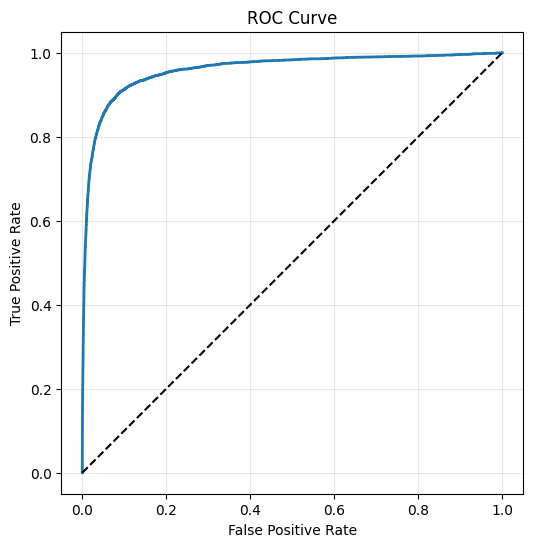

In [12]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_score)

def plot_roc_curve(fpr, tpr, label=None):
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], "k--")  # Diagonal line
    plt.axis("square")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.grid(True, alpha=0.3)
    if label:
        plt.legend(loc="lower right")

plot_roc_curve(fpr, tpr)
plt.show()

SGD ROC AUC: 0.9605
Random Forest ROC AUC: 0.9985


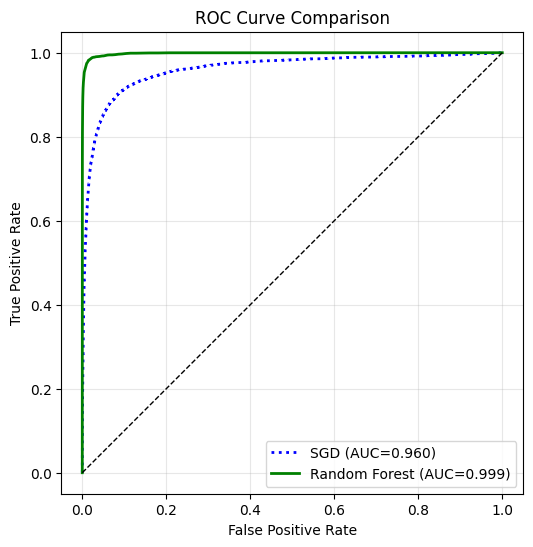

In [13]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier

# AUC do classificador SGD (scores vindos de decision_function)
sgd_auc = roc_auc_score(y_train_5, y_score)
print(f"SGD ROC AUC: {sgd_auc:.4f}")

# Random Forest para comparar ROC AUC
forest_clf = RandomForestClassifier(random_state=42, n_estimators=200, n_jobs=-1)
y_probas_forest = cross_val_predict(
    forest_clf,
    X_train,
    y_train_5,
    cv=3,
    method="predict_proba",
)
y_scores_forest = y_probas_forest[:, 1]
forest_auc = roc_auc_score(y_train_5, y_scores_forest)
print(f"Random Forest ROC AUC: {forest_auc:.4f}")

# Curvas ROC comparativas
fpr_sgd, tpr_sgd, _ = roc_curve(y_train_5, y_score)
fpr_forest, tpr_forest, _ = roc_curve(y_train_5, y_scores_forest)

plt.figure(figsize=(7, 6))
plt.plot(fpr_sgd, tpr_sgd, "b:", linewidth=2, label=f"SGD (AUC={sgd_auc:.3f})")
plt.plot(fpr_forest, tpr_forest, "g-", linewidth=2, label=f"Random Forest (AUC={forest_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")
plt.show()

## Multiclassification:
- One vs One
    - Each class is compared against every other class, resulting in multiple binary classifiers.
- One vs Rest
    - Each class is compared against all other classes combined, resulting in a single binary classifier for each class.

In [14]:
from sklearn.svm import SVCSVC
svm_clf = SVC()
svm_clf.fit(X_train, y_train)
svm_clf.predict([some_digit])

ImportError: cannot import name 'SVCSVC' from 'sklearn.svm' (c:\Users\marco\Documents\code_classes\machine_learning_review\.venv\Lib\site-packages\sklearn\svm\__init__.py)

In [ ]:
some_digit_scores = svm_clf.decision_function([some_digit])
print("SVM decision scores:", some_digit_scores)

In [ ]:
np.argmax(some_digit_scores)

In [ ]:
svm_clf.classes_

In [ ]:
svm_clf.classes_[5]

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
ovr_clf = OneVsRestClassifier(SVC())
ovr_clf.fit(X_train, y_train)
ovr_clf.predict([some_digit])
len(ovr_clf.estimators_)

In [ ]:
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])